In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\Users\siril\OneDrive\Desktop\CV Projects\inventory_demand_stockout_risk_dataset\inventory_demand_stockout_risk_dataset.csv")
df

,product_id,date,store_id,category,region,supplier_id,current_stock,daily_demand,lead_time_days,supplier_reliability_score,promotion_active,weather_impact,unit_price,stockout_risk_score,stockout_risk,inventory_days,reorder_point,inventory_value,potential_revenue_loss
0,P0003,2025-01-01,S020,Electronics,East,SUP005,57,18,2,0.93,1,-0.02,558.70,0.000,Low,3.17,36,31845.90,0.00
1,P0182,2025-01-01,S023,Grocery,West,SUP025,672,42,11,0.84,0,-0.15,181.22,0.000,Low,16.00,462,121779.84,0.00
2,P0196,2025-01-01,S023,Electronics,South,SUP025,68,16,5,0.76,0,-0.13,430.86,0.141,Low,4.25,80,29298.48,5170.32
3,P0079,2025-01-01,S028,Electronics,South,SUP005,360,25,11,0.95,1,-0.15,433.84,0.000,Low,14.40,275,156182.40,0.00
4,P0161,2025-01-01,S023,Sports,South,SUP001,34,23,5,0.85,0,-0.17,86.45,0.422,Medium,1.48,115,2939.30,7002.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,P0072,2026-08-20,S019,Home & Kitchen,East,SUP009,443,21,14,0.76,1,-0.22,395.48,0.000,Low,21.10,294,175197.64,0.00
11996,P0068,2026-08-20,S009,Electronics,West,SUP010,215,17,7,0.87,0,0.06,639.85,0.000,Low,12.65,119,137567.75,0.00
11997,P0069,2026-08-20,S019,Clothing,West,SUP009,370,35,4,0.90,0,0.16,879.63,0.000,Low,10.57,140,325463.10,0.00
11998,P0176,2026-08-20,S013,Grocery,West,SUP006,447,22,10,0.88,0,-0.04,736.08,0.000,Low,20.32,220,329027.76,0.00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  12000 non-null  object 
 1   date                        12000 non-null  object 
 2   store_id                    12000 non-null  object 
 3   category                    12000 non-null  object 
 4   region                      12000 non-null  object 
 5   supplier_id                 12000 non-null  object 
 6   current_stock               12000 non-null  int64  
 7   daily_demand                12000 non-null  int64  
 8   lead_time_days              12000 non-null  int64  
 9   supplier_reliability_score  11880 non-null  float64
 10  promotion_active            12000 non-null  int64  
 11  weather_impact              11880 non-null  float64
 12  unit_price                  12000 non-null  float64
 13  stockout_risk_score         120

In [5]:
df.describe()

,current_stock,daily_demand,lead_time_days,supplier_reliability_score,promotion_active,weather_impact,unit_price,stockout_risk_score,inventory_days,reorder_point,inventory_value,potential_revenue_loss
count,12000.000000,12000.000000,12000.000000,11880.000000,12000.000000,11880.000000,12000.000000,12000.000000,12000.000000,12000.000000,1.200000e+04,12000.000000
mean,321.272667,25.457917,8.078500,0.820338,0.219167,0.000982,453.174363,0.107251,12.653991,205.816417,1.459385e+05,17679.503508
std,268.413165,13.739055,3.723505,0.097807,0.413699,0.144310,256.470566,0.177970,7.109588,154.819477,1.639505e+05,46752.662457
min,4.000000,6.000000,2.000000,0.650000,0.000000,-0.250000,8.090000,0.000000,0.500000,12.000000,1.227600e+02,0.000000
25%,127.000000,16.000000,5.000000,0.740000,0.000000,-0.122500,229.320000,0.000000,6.387500,95.000000,3.466806e+04,0.000000
50%,255.000000,22.000000,8.000000,0.820000,0.000000,0.000000,454.110000,0.000000,12.720000,165.000000,9.249282e+04,0.000000
75%,437.250000,31.000000,11.000000,0.910000,0.000000,0.130000,674.622500,0.180000,18.792500,270.000000,1.995467e+05,7986.965000
max,2326.000000,103.000000,14.000000,0.990000,1.000000,0.250000,899.880000,0.709000,25.000000,1183.000000,1.888570e+06,621256.840000


In [6]:
# Check missing values
print("Missing values before treatment:")
print(df.isnull().sum())

# Calculate medians
supplier_median = df["supplier_reliability_score"].median()
weather_median = df["weather_impact"].median()

# Fill missing values
df["supplier_reliability_score"] = df[
    "supplier_reliability_score"
].fillna(supplier_median)

df["weather_impact"] = df[
    "weather_impact"
].fillna(weather_median)

# Check missing values after treatment
print("\nMissing values after treatment:")
print(df.isnull().sum())

Missing values before treatment:
product_id                      0
date                            0
store_id                        0
category                        0
region                          0
supplier_id                     0
current_stock                   0
daily_demand                    0
lead_time_days                  0
supplier_reliability_score    120
promotion_active                0
weather_impact                120
unit_price                      0
stockout_risk_score             0
stockout_risk                   0
inventory_days                  0
reorder_point                   0
inventory_value                 0
potential_revenue_loss          0
dtype: int64

Missing values after treatment:
product_id                    0
date                          0
store_id                      0
category                      0
region                        0
supplier_id                   0
current_stock                 0
daily_demand                  0
lead_time_days     

In [7]:
df['product_id'].unique()

array(['P0003', 'P0182', 'P0196', 'P0079', 'P0161', 'P0183', 'P0109',
       'P0144', 'P0074', 'P0188', 'P0106', 'P0167', 'P0054', 'P0097',
       'P0062', 'P0181', 'P0113', 'P0021', 'P0171', 'P0032', 'P0159',
       'P0012', 'P0105', 'P0077', 'P0187', 'P0192', 'P0020', 'P0124',
       'P0172', 'P0131', 'P0194', 'P0157', 'P0135', 'P0101', 'P0121',
       'P0064', 'P0150', 'P0145', 'P0175', 'P0006', 'P0120', 'P0052',
       'P0128', 'P0076', 'P0195', 'P0107', 'P0103', 'P0184', 'P0143',
       'P0085', 'P0147', 'P0056', 'P0096', 'P0112', 'P0114', 'P0009',
       'P0028', 'P0178', 'P0090', 'P0005', 'P0084', 'P0139', 'P0179',
       'P0044', 'P0200', 'P0140', 'P0058', 'P0154', 'P0111', 'P0119',
       'P0108', 'P0136', 'P0008', 'P0035', 'P0104', 'P0024', 'P0063',
       'P0173', 'P0185', 'P0138', 'P0017', 'P0081', 'P0176', 'P0158',
       'P0165', 'P0133', 'P0026', 'P0039', 'P0069', 'P0110', 'P0036',
       'P0164', 'P0072', 'P0094', 'P0180', 'P0102', 'P0046', 'P0066',
       'P0071', 'P00

In [8]:
df['store_id'].unique()

array(['S020', 'S023', 'S028', 'S009', 'S004', 'S003', 'S022', 'S027',
       'S015', 'S005', 'S011', 'S030', 'S010', 'S012', 'S029', 'S017',
       'S018', 'S026', 'S021', 'S019', 'S008', 'S006', 'S025', 'S013',
       'S024', 'S014', 'S001', 'S002', 'S016', 'S007'], dtype=object)

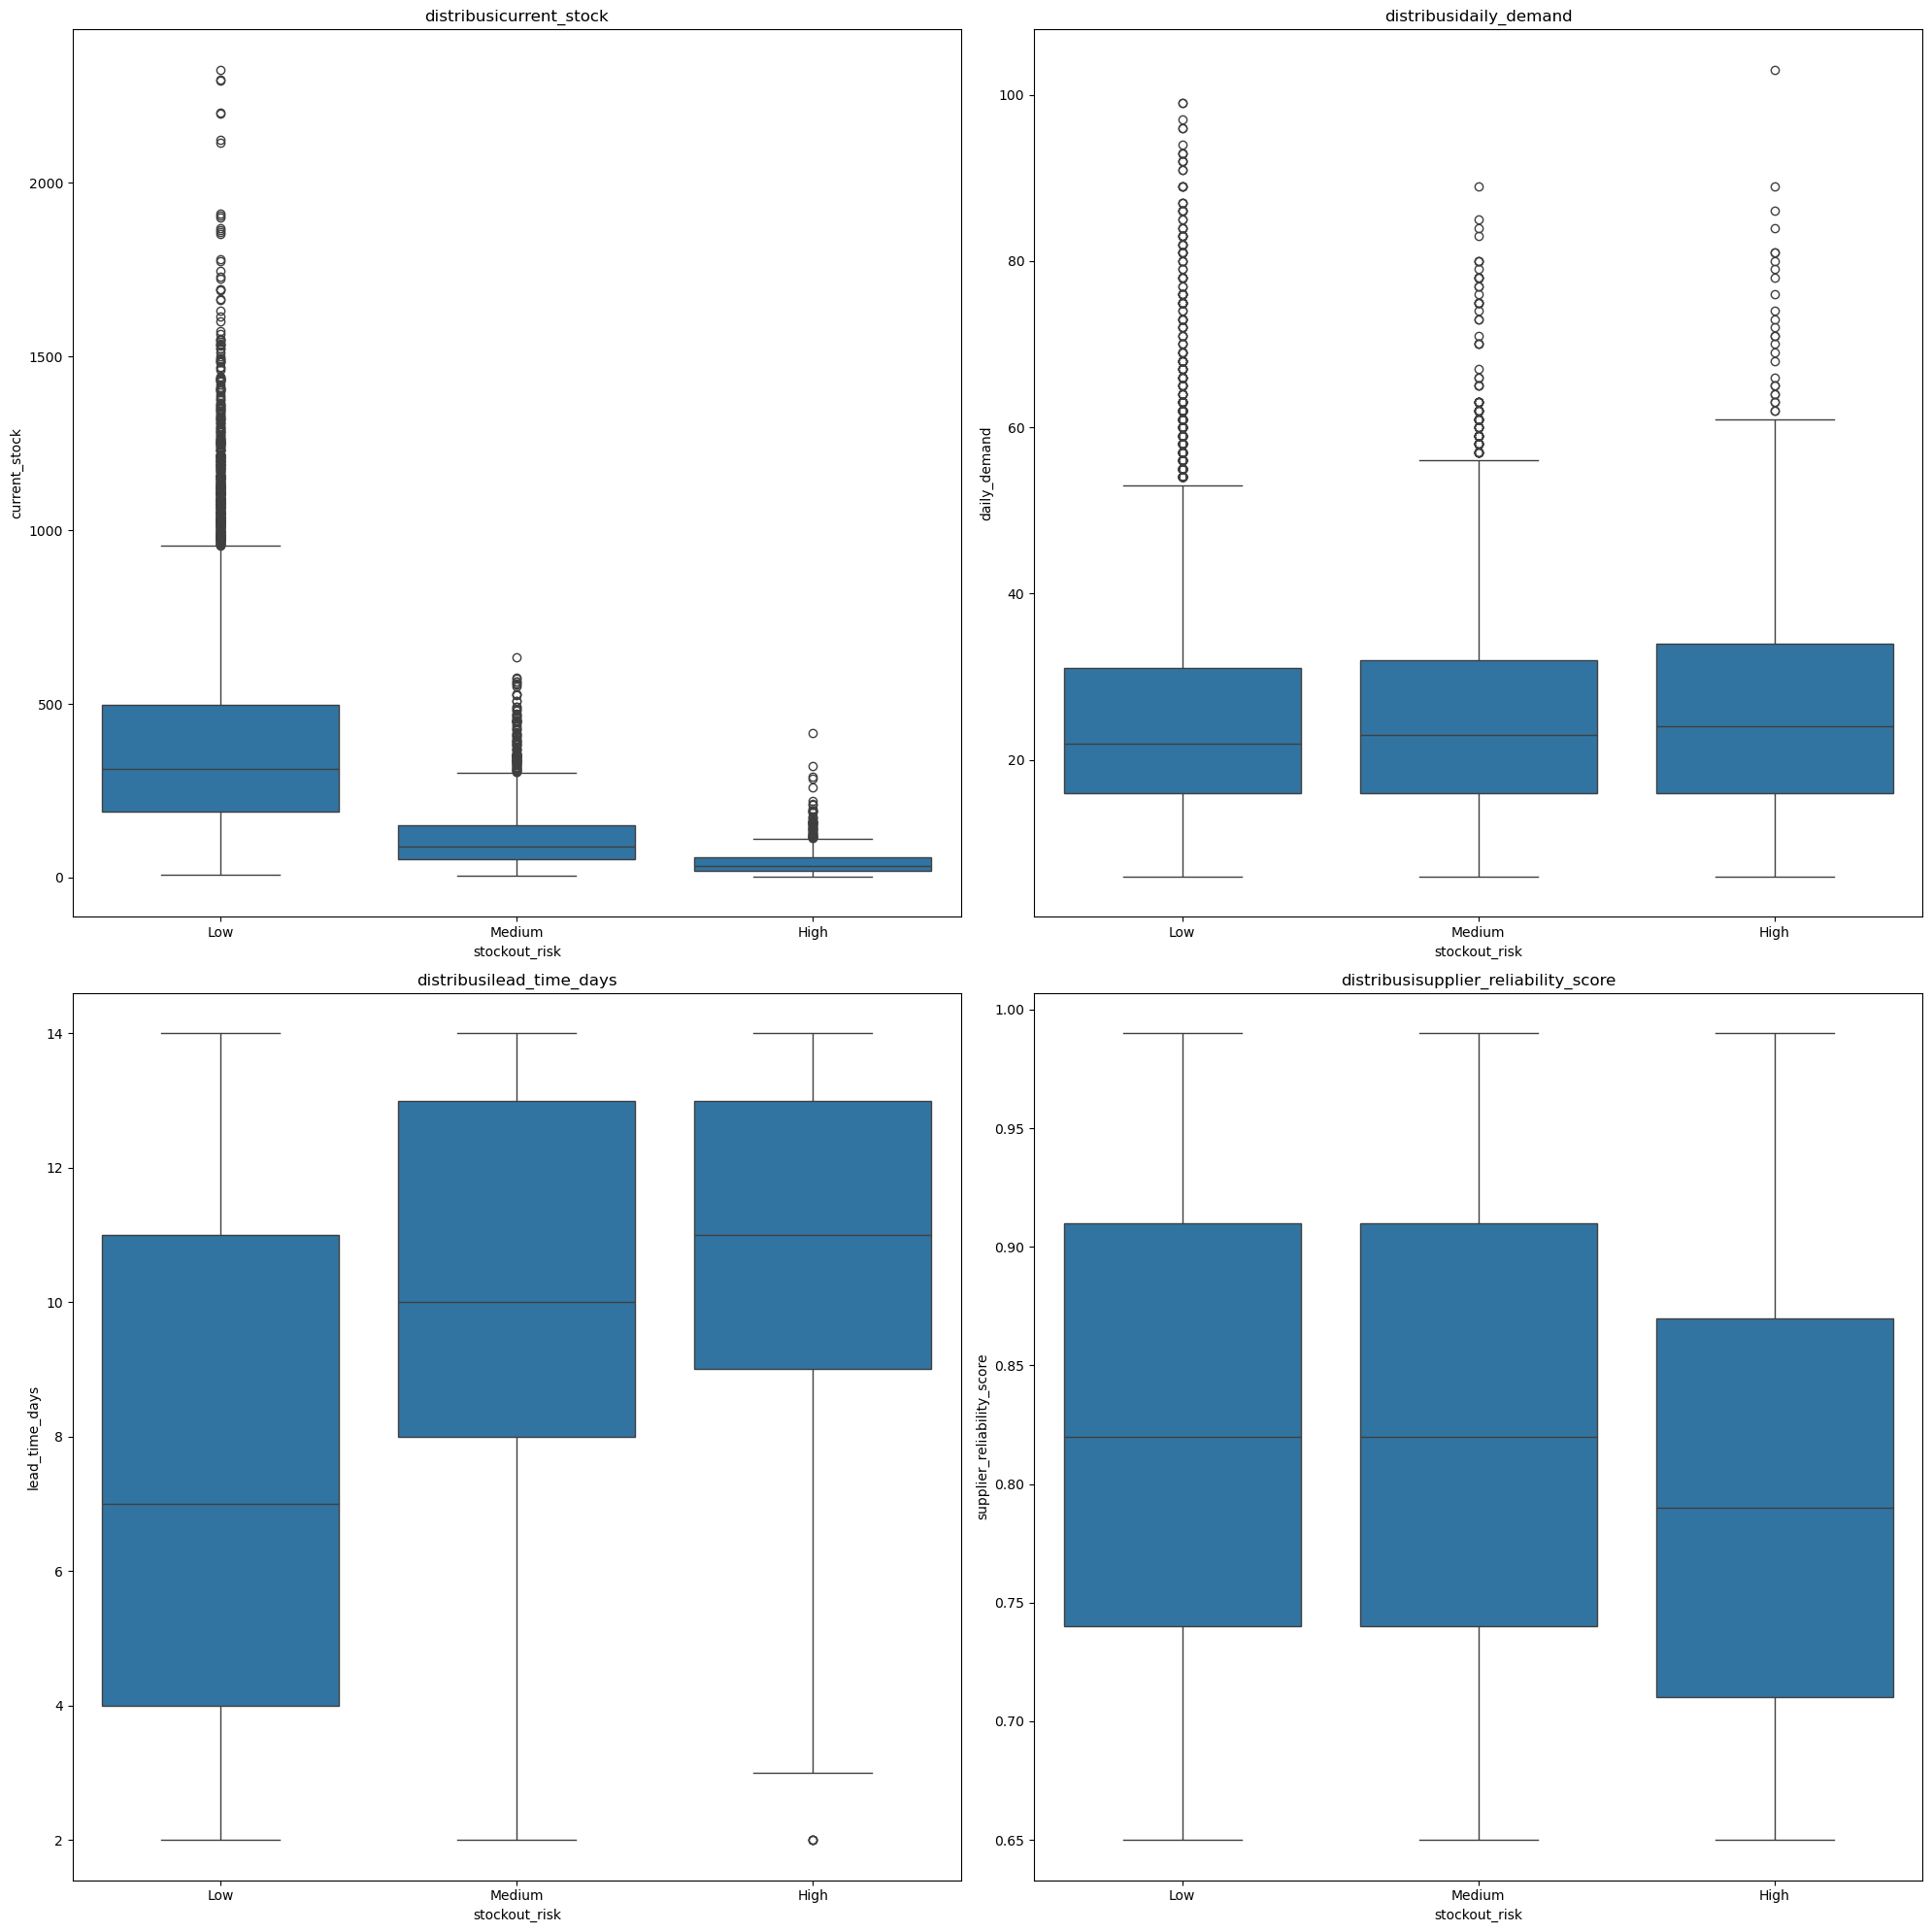

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

features=['current_stock','daily_demand','lead_time_days','supplier_reliability_score']
fig,axes=plt.subplots(nrows=2,ncols=2,figsize=(20,20))
axes=axes.flatten()
for i, col in enumerate (features):
    sns.boxplot(data=df, x='stockout_risk',y=col,ax=axes[i])
    axes[i].set_title(f'distribusi{col}')
for j in range(i+1,len (axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [10]:
df['date'] = pd.to_datetime(df['date'])
df['date'].dtype

dtype('<M8[ns]')

In [19]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.month_name()
df['day'] = df['date'].dt.day
df['week'] = df['date'].dt.isocalendar().week

In [21]:
df[['date','year','month','month_name','week']].head()

,date,year,month,month_name,week
0,2025-01-01,2025,1,January,1
1,2025-01-01,2025,1,January,1
2,2025-01-01,2025,1,January,1
3,2025-01-01,2025,1,January,1
4,2025-01-01,2025,1,January,1


In [25]:
df['stockout_risk'].value_counts()

stockout_risk
Low       9476
Medium    1841
High       683
Name: count, dtype: int64

In [27]:
df['stockout_risk'].value_counts(normalize=True) * 100

stockout_risk
Low       78.966667
Medium    15.341667
High       5.691667
Name: proportion, dtype: float64

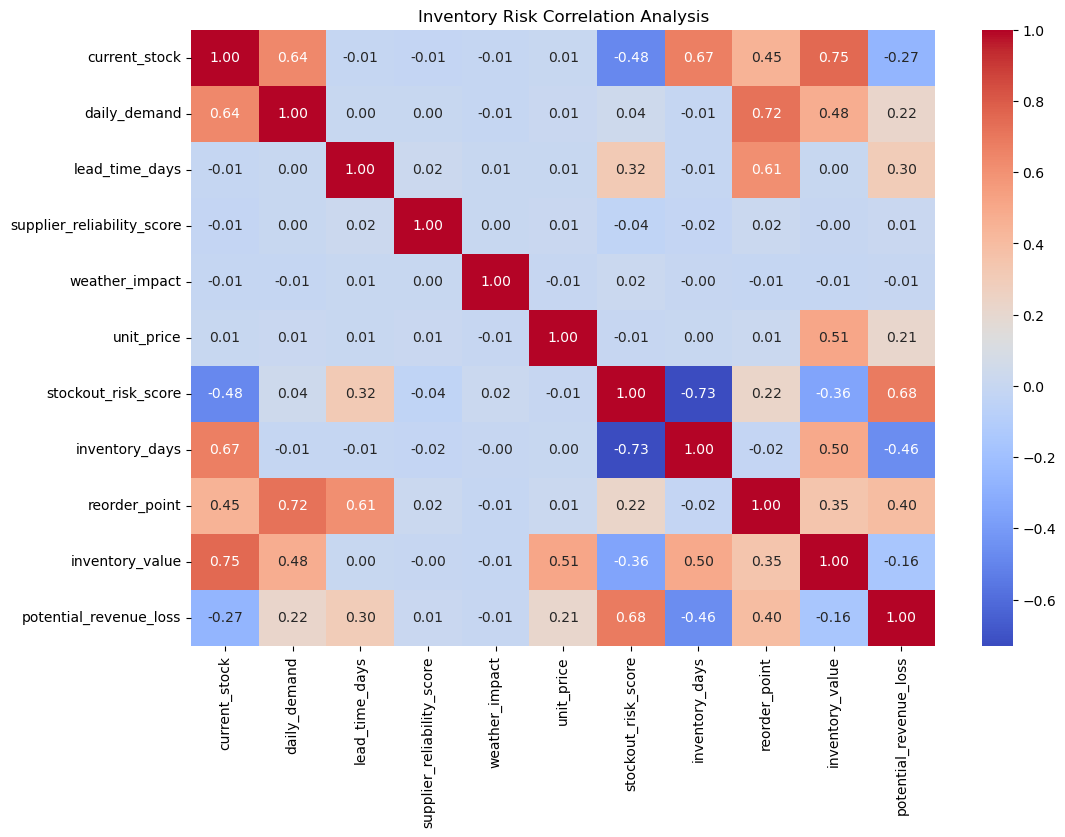

In [35]:
# relationships between numerical variables.
numeric_cols = [
    'current_stock',
    'daily_demand',
    'lead_time_days',
    'supplier_reliability_score',
    'weather_impact',
    'unit_price',
    'stockout_risk_score',
    'inventory_days',
    'reorder_point',
    'inventory_value',
    'potential_revenue_loss'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Inventory Risk Correlation Analysis')

plt.show()

In [39]:
# which categories have the biggest inventory problem.
category_analysis = df.groupby('category').agg(
    total_stock=('current_stock','sum'),
    avg_demand=('daily_demand','mean'),
    avg_risk_score=('stockout_risk_score','mean'),
    revenue_loss=('potential_revenue_loss','sum'),
    inventory_value=('inventory_value','sum')
).reset_index()

category_analysis.sort_values(
    'revenue_loss',
    ascending=False
)

,category,total_stock,avg_demand,avg_risk_score,revenue_loss,inventory_value
3,Grocery,1137336,43.912162,0.111470,63674326.18,5.193048e+08
0,Beauty,698548,27.699700,0.109176,39646640.06,3.140074e+08
1,Clothing,631141,25.082300,0.110021,37579973.56,2.882919e+08
4,Home & Kitchen,563598,22.644479,0.102781,28836076.76,2.549419e+08
5,Sports,430111,17.298721,0.101965,22057987.62,1.950975e+08
2,Electronics,394538,15.282178,0.107659,20359037.92,1.796189e+08


In [43]:
# Regional Analysis
region_analysis = df.groupby('region').agg(
    total_stock=('current_stock','sum'),
    avg_daily_demand=('daily_demand','mean'),
    avg_risk_score=('stockout_risk_score','mean'),
    revenue_loss=('potential_revenue_loss','sum'),
    inventory_value=('inventory_value','sum')
).reset_index()

region_analysis.sort_values(
    'revenue_loss',
    ascending=False
)

,region,total_stock,avg_daily_demand,avg_risk_score,revenue_loss,inventory_value
1,North,937350,25.524756,0.110271,56351088.38,4.306732e+08
0,East,959534,25.604888,0.108536,54537959.23,4.339821e+08
3,West,989293,25.302521,0.105594,53386062.42,4.460042e+08
2,South,969095,25.407556,0.104703,47878932.07,4.406029e+08


In [47]:
# Supplier Analysis

supplier_analysis = df.groupby('supplier_id').agg(
    reliability=('supplier_reliability_score','mean'),
    avg_lead_time=('lead_time_days','mean'),
    avg_risk=('stockout_risk_score','mean'),
    revenue_loss=('potential_revenue_loss','sum')
).reset_index()

supplier_analysis.sort_values(
    'avg_risk',
    ascending=False
)

,supplier_id,reliability,avg_lead_time,avg_risk,revenue_loss
34,SUP035,0.820684,8.149837,0.123883,6236455.99
39,SUP040,0.825612,8.116418,0.122122,5938421.56
4,SUP005,0.815347,8.254125,0.120531,5486561.77
23,SUP024,0.817010,8.069767,0.119561,5653292.22
30,SUP031,0.824923,7.861538,0.118415,5086864.32
1,SUP002,0.819894,8.109929,0.116837,6163251.67
7,SUP008,0.817621,8.334677,0.116565,5256886.34
0,SUP001,0.823079,8.526490,0.116391,5799664.15
16,SUP017,0.826059,7.990228,0.116199,5362405.72
2,SUP003,0.821169,8.003247,0.115529,7356036.02


In [53]:
# Inventory Health Flag
df['inventory_health'] = np.where(
    df['current_stock'] <= df['reorder_point'],
    'Reorder Required',
    'Healthy'
)
df['inventory_health'].value_counts()

inventory_health
Healthy             8230
Reorder Required    3770
Name: count, dtype: int64

In [87]:
# Create Risk Priority
df['priority'] = pd.cut(
    df['potential_revenue_loss'],
    bins=[-1, 5000, 20000, float('inf')],
    labels=['Low Priority','Medium Priority','High Priority']
)
df['priority'].value_counts()

priority
Low Priority       8771
High Priority      2349
Medium Priority     880
Name: count, dtype: int64

In [61]:
df.to_csv(
    'inventory_cleaned.csv',
    index=False
)

In [65]:
from sqlalchemy import create_engine

username = "root"
password = "1234"
host = "localhost"
port = "3306"
database = "inventory_demand"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

table_name = "inventory_demand"  
df.to_sql(table_name, engine, if_exists="replace", index=False)

# Read back sample
pd.read_sql("SELECT * FROM inventory_demand LIMIT 5;", engine)

,product_id,date,store_id,category,region,supplier_id,current_stock,daily_demand,lead_time_days,supplier_reliability_score,...,inventory_value,potential_revenue_loss,year,month,month_name,day,week,inventory_health,demand_pressure,priority
0,P0003,2025-01-01,S020,Electronics,East,SUP005,57,18,2,0.93,...,31845.90,0.00,2025,1,January,1,1,Healthy,0.315789,Low Priority
1,P0182,2025-01-01,S023,Grocery,West,SUP025,672,42,11,0.84,...,121779.84,0.00,2025,1,January,1,1,Healthy,0.062500,Low Priority
2,P0196,2025-01-01,S023,Electronics,South,SUP025,68,16,5,0.76,...,29298.48,5170.32,2025,1,January,1,1,Reorder Required,0.235294,Medium Priority
3,P0079,2025-01-01,S028,Electronics,South,SUP005,360,25,11,0.95,...,156182.40,0.00,2025,1,January,1,1,Healthy,0.069444,Low Priority
4,P0161,2025-01-01,S023,Sports,South,SUP001,34,23,5,0.85,...,2939.30,7002.45,2025,1,January,1,1,Reorder Required,0.676471,Medium Priority
